In [1]:
import cfe

cfe.logger.setLevel("DEBUG")

cfe.settings.backend = "conda"

[10/22/2025 04:59:48] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [2]:
fadata = cfe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.add_prior_information(start_cell="cell_000")

fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    unserialize trajectory dict: 'ref'                                                                                                                                       
                      DEBUG    parse 'MilestoneWrapper' object for ref                                                                                                                              

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe', 'id'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced'

In [3]:
parameters = {"prune_milestone": False}
method = cfe.method.FateMethod(method_name="stavia")
method.infer_trajectory(fadata, parameters)

                      DEBUG    CondaBackend __init__                                                                                                                                                    
[10/22/2025 04:59:49] DEBUG    Conda environment 'stavia' found.                                                                                                                                        
[10/22/2025 04:59:52] DEBUG    Conda environment 'stavia' is available: Python 3.10.14                                                                                                                  
                      DEBUG    Loaded function 'stavia': <function stavia at 0x70c87bae4550>                                                                                                            
                      INFO     method backend loaded: CondaBackend: stavia in conda env 'stavia'                                                                                                    

[10/22/2025 05:00:30] DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:20251022_165952__stavia-conda__kiJmb7A0LJ, basis:X_umap.                                                               
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
                      DEBUG    add waypoints shape is (210, 500) for '20251022_165952__stavia-conda__kiJmb7A0LJ', finished!                                                                         

<Axes: title={'center': 'stavia-conda(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

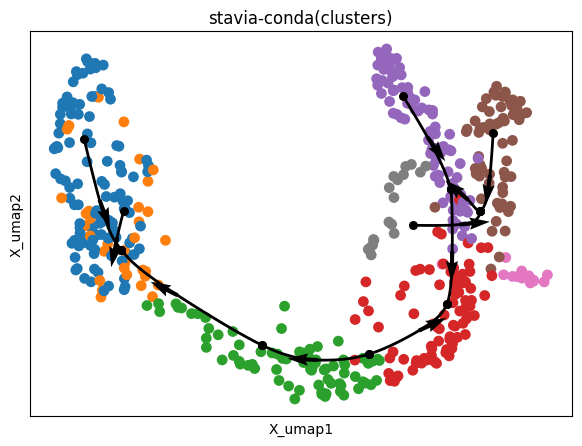

In [4]:
# fix for isolated milestones and cells.
cfe.plot.plot_trajectory(fadata, color="clusters")

In [8]:
if cfe.settings.backend == "conda":
    method.method_backend.export_conda_env()
    # TODO: only need save key packages manually, delete build info and other unimportant info

[10/22/2025 05:01:57] INFO     successfully export conda environment 'stavia' to '/root/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/environment/stavia.yaml'                              


In [9]:
if cfe.settings.backend == "conda":
    method.method_backend.generate_dockerfile()

[10/22/2025 05:02:07] DEBUG    detected python version: 3.10.14                                                                                                                                         
                      DEBUG    write pip requirements to '/root/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/requirement/stavia.txt'                                                       
                      INFO     write dockerfile base template.dockerfile to '/root/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/Dockerfile/stavia.dockerfile'                              
